# 04. Кореляція кількості студентів у ЗВО та кількості студентів на одного викладача

Мета ноутбука - перевірити зв'язок між кількістю студентів в окремому ЗВО та кількістю студентів на одного викладача в тому самому ЗВО. У розрахунок беруться тільки спостереження за 2022-2023 роки. Якщо за ці роки немає валідних даних щодо кількості студентів або академічного персоналу, такі спостереження виключаються з аналітичної вибірки.


## План

1. Завантажити очищений ETER-набір `data/processed/df_base_clean.csv`.
2. Перевірити наявність потрібних полів: ідентифікатор ЗВО, країна, рік, кількість студентів і `academic_personnel_fte`.
3. Залишити тільки спостереження за 2022 і 2023 роки. Усі роки поза цим діапазоном виключити до розрахунків.
4. Сформувати показник кількості студентів у ЗВО `students_total_calc`: використати `students_isced5_7_total` і додати `students_isced8`; якщо `students_isced5_7_total` відсутній, використати суму доступних `students_isced5`, `students_isced6`, `students_isced7`, `students_isced7_long_degree`.
5. Сформувати показник навантаження на викладача: `students_per_teacher = students_total_calc / academic_personnel_fte`.
6. Виключити спостереження, де за 2022-2023 роки відсутня валідна кількість студентів, відсутня валідна кількість викладачів або неможливо порахувати `students_per_teacher`.
7. Для кожного ЗВО вибрати одне спостереження з доступних за 2022-2023 роки: пріоритет 2023, якщо дані є; інакше 2022.
8. Зафіксувати таблицю винятків: скільки рядків втрачено через відсутність даних за 2022-2023 роки, відсутність студентів, відсутність викладачів і нульові/від'ємні значення.
9. Порахувати Pearson і Spearman кореляції між кількістю студентів у ЗВО та кількістю студентів на одного викладача по всій аналітичній вибірці.
10. Порахувати ті самі кореляції окремо за країнами, де є достатня кількість валідних ЗВО, наприклад `n >= 10`.
11. Провести аналіз чутливості: повторити загальну кореляцію окремо для 2022 і 2023 років, якщо в кожному році достатньо спостережень.
12. Зберегти результатні таблиці в `data/processed/`: вхідну аналітичну вибірку, загальні кореляції, кореляції за країнами, кореляції за роками, таблицю винятків і покриття за країнами.
13. Побудувати діаграму розсіювання: `students_total_calc` проти `students_per_teacher` з лог-шкалою для кількості студентів.
14. Зберегти всі графіки в `figures/` з префіксом `04_` згідно з правилами репозиторію.
15. Наприкінці ноутбука коротко інтерпретувати знак, силу та статистичну значущість кореляцій, окремо зазначити обмеження через пропуски даних за 2022-2023 роки.


## 1. Імпорт бібліотек і налаштування

In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy import stats
except ImportError:
    stats = None

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "df_base_clean.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


NOTEBOOK_PREFIX = "04_"


def save_figure(filename, fig=None, dpi=200):
    normalized_name = filename if filename.startswith(NOTEBOOK_PREFIX) else f"{NOTEBOOK_PREFIX}{filename}"
    figure = fig if fig is not None else plt.gcf()
    path = FIGURES_DIR / normalized_name
    figure.savefig(path, dpi=dpi, bbox_inches="tight")
    return path


DATA_PATH

PosixPath('/Users/ssyvon41kkk/PycharmProjects/ETER.EDBO/data/processed/df_base_clean.csv')

## 2. Завантаження очищених даних

In [34]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Не найден файл: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 29,591
Columns: 57


,record_id,institution_id,institution_name,institution_name_en,year,country_code,nuts2,nuts3,city,latitude,...,flag_foreign_students_isced7_long_degree,flag_foreign_students_isced5_7_total,flag_foreign_students_isced8,flag_academic_personnel_fte,flag_total_personnel_fte,flag_support_admin_personnel_fte,flag_total_current_expenditure,flag_total_current_revenues,flag_third_party_funding,flag_rd_expenditure
0,AD0001.2023,AD0001,Universitat d'Andorra,University of Andorra,2023,AD,AD00,AD000,Sant Julià de Lòria,42.463227,...,NaN,NaN,NaN,NaN,NaN,NaN,d,NaN,NaN,NaN
1,AL0001.2023,AL0001,Universiteti i Tiranës,University of Tirana,2023,AL,AL02,AL022,Tirana,41.318093,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL0002.2023,AL0002,Universiteti Politeknik i Tiranës,Polytechnic University of Tirana,2023,AL,AL02,AL022,Tirana,41.316598,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AL0003.2023,AL0003,Universiteti Bujqësor i Tiranës,Agricultural University of Tirana,2023,AL,AL02,AL022,Tirana,41.363000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AL0004.2023,AL0004,"Universiteti i Elbasanit ""Aleksandër Xhuvani""","University of Elbasan, Aleksander Xhuvani",2023,AL,AL02,AL021,Elbasan,41.122408,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Підготовка показників

In [35]:
required_cols = [
    "country_code",
    "year",
    "institution_id",
    "institution_name_en",
    "students_isced5_7_total",
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
    "students_isced8",
    "academic_personnel_fte",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"В df_base_clean.csv отсутствуют нужные колонки: {missing_cols}")

source_rows = len(df)
rows_outside_2022_2023 = (~df["year"].isin([2022, 2023])).sum()
work = df.loc[df["year"].isin([2022, 2023]), required_cols].copy()

numeric_cols = [
    "students_isced5_7_total",
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
    "students_isced8",
    "academic_personnel_fte",
]

for col in numeric_cols:
    work[col] = pd.to_numeric(work[col], errors="coerce")

isced_5_7_fallback = work[[
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
]].sum(axis=1, min_count=1)

students_5_7 = work["students_isced5_7_total"].combine_first(isced_5_7_fallback)
work["students_total_calc"] = students_5_7.add(work["students_isced8"].fillna(0), fill_value=np.nan)
work["students_per_teacher"] = work["students_total_calc"] / work["academic_personnel_fte"]

work[
    [
        "students_isced5_7_total",
        "students_isced8",
        "students_total_calc",
        "academic_personnel_fte",
        "students_per_teacher",
    ]
].describe()

/Users/ssyvon41kkk/PycharmProjects/ETER.EDBO/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,students_isced5_7_total,students_isced8,students_total_calc,academic_personnel_fte,students_per_teacher
count,5.945000e+03,4660.000000,6.336000e+03,3470.000000,3467.000000
mean,8.805859e+03,336.979386,8.562446e+03,587.260764,inf
std,3.877164e+04,824.377696,3.782760e+04,905.038872,NaN
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,5.530000e+02,0.000000,4.880000e+02,64.711700,10.053007
50%,2.145000e+03,8.500000,1.779000e+03,199.925000,14.996548
75%,9.985000e+03,256.250000,9.430750e+03,693.750000,21.573913
max,1.890223e+06,9420.000000,1.891766e+06,7535.000000,inf


## 4. Фільтрація спостережень

In [36]:
has_valid_students = work["students_total_calc"].notna() & (work["students_total_calc"] > 0)
has_valid_academic_personnel = (
    work["academic_personnel_fte"].notna() & (work["academic_personnel_fte"] > 0)
)
has_valid_students_per_teacher = (
    work["students_per_teacher"].replace([np.inf, -np.inf], np.nan).notna()
    & (work["students_per_teacher"] > 0)
)

exclusions = pd.DataFrame(
    {
        "rule": [
            "source_rows",
            "excluded_rows_outside_2022_2023",
            "rows_in_2022_2023",
            "missing_students_total_calc",
            "zero_or_negative_students_total_calc",
            "missing_academic_personnel_fte",
            "zero_or_negative_academic_personnel_fte",
            "invalid_students_per_teacher",
        ],
        "rows": [
            source_rows,
            rows_outside_2022_2023,
            len(work),
            work["students_total_calc"].isna().sum(),
            (work["students_total_calc"].notna() & (work["students_total_calc"] <= 0)).sum(),
            work["academic_personnel_fte"].isna().sum(),
            (work["academic_personnel_fte"].notna() & (work["academic_personnel_fte"] <= 0)).sum(),
            (~has_valid_students_per_teacher).sum(),
        ],
    }
)

valid = work.loc[
    has_valid_students
    & has_valid_academic_personnel
    & has_valid_students_per_teacher
].copy()

exclusions = pd.concat(
    [
        exclusions,
        pd.DataFrame({"rule": ["valid_rows_before_latest_year_selection"], "rows": [len(valid)]}),
    ],
    ignore_index=True,
)

exclusions

,rule,rows
0,source_rows,29591
1,excluded_rows_outside_2022_2023,22989
2,rows_in_2022_2023,6602
3,missing_students_total_calc,266
4,zero_or_negative_students_total_calc,196
5,missing_academic_personnel_fte,3132
6,zero_or_negative_academic_personnel_fte,18
7,invalid_students_per_teacher,3153
8,valid_rows_before_latest_year_selection,3449


## 5. Вибір останнього доступного року для кожного ЗВО

In [37]:
analysis_df = (
    valid.sort_values(["institution_id", "year"])
    .groupby("institution_id", as_index=False)
    .tail(1)
    .sort_values(["country_code", "institution_id"])
    .reset_index(drop=True)
)

analysis_df = analysis_df[
    [
        "country_code",
        "institution_id",
        "institution_name_en",
        "year",
        "students_total_calc",
        "academic_personnel_fte",
        "students_per_teacher",
    ]
].copy()

exclusions = pd.concat(
    [
        exclusions,
        pd.DataFrame(
            {
                "rule": ["valid_institutions_after_latest_year_selection"],
                "rows": [analysis_df["institution_id"].nunique()],
            }
        ),
    ],
    ignore_index=True,
)

coverage_summary = pd.Series(
    {
        "institutions": analysis_df["institution_id"].nunique(),
        "countries": analysis_df["country_code"].nunique(),
        "observations_2023": (analysis_df["year"] == 2023).sum(),
        "observations_2022": (analysis_df["year"] == 2022).sum(),
        "median_students": analysis_df["students_total_calc"].median(),
        "median_academic_personnel_fte": analysis_df["academic_personnel_fte"].median(),
        "median_students_per_teacher": analysis_df["students_per_teacher"].median(),
    }
)

coverage_summary

institutions                     1915.000000
countries                          27.000000
observations_2023                1633.000000
observations_2022                 282.000000
median_students                  3025.000000
median_academic_personnel_fte     190.000000
median_students_per_teacher        14.657895
dtype: float64

## 6. Кореляція по всій вибірці

In [38]:
def correlation_rows(data, group_label="all_heis", x_col="students_total_calc", y_col="students_per_teacher"):
    clean = data[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    n = len(clean)

    rows = []
    for method in ["pearson", "spearman"]:
        if n < 3 or clean[x_col].nunique() < 2 or clean[y_col].nunique() < 2:
            corr = np.nan
            p_value = np.nan
        elif stats is not None and method == "pearson":
            corr, p_value = stats.pearsonr(clean[x_col], clean[y_col])
        elif stats is not None and method == "spearman":
            corr, p_value = stats.spearmanr(clean[x_col], clean[y_col])
        else:
            corr = clean[x_col].corr(clean[y_col], method=method)
            p_value = np.nan

        rows.append(
            {
                "group": group_label,
                "method": method,
                "correlation": corr,
                "p_value": p_value,
                "n_institutions": n,
            }
        )

    return rows


correlation_all = pd.DataFrame(correlation_rows(analysis_df))
correlation_all

,group,method,correlation,p_value,n_institutions
0,all_heis,pearson,0.129460,1.304159e-08,1915
1,all_heis,spearman,0.259235,8.825914e-31,1915


## 7. Кореляції за країнами та роками

In [39]:
MIN_COUNTRY_N = 10
MIN_YEAR_N = 3

country_counts = (
    analysis_df.groupby("country_code", as_index=False)
    .agg(n_institutions=("institution_id", "nunique"))
    .sort_values("n_institutions", ascending=False)
)

eligible_countries = country_counts.loc[country_counts["n_institutions"] >= MIN_COUNTRY_N, "country_code"]

country_rows = []
for country_code, country_df in analysis_df.loc[analysis_df["country_code"].isin(eligible_countries)].groupby("country_code"):
    country_rows.extend(correlation_rows(country_df, group_label=country_code))

correlation_by_country = pd.DataFrame(country_rows).rename(columns={"group": "country_code"})
correlation_by_country = correlation_by_country.sort_values(["method", "country_code"]).reset_index(drop=True)

by_year_rows = []
for year, year_df in valid.groupby("year"):
    if len(year_df) >= MIN_YEAR_N:
        by_year_rows.extend(correlation_rows(year_df, group_label=year))

correlation_by_year = pd.DataFrame(by_year_rows).rename(columns={"group": "year"})
correlation_by_year = correlation_by_year.sort_values(["year", "method"]).reset_index(drop=True)

country_counts.head(20), correlation_by_country.head(20), correlation_by_year

(   country_code  n_institutions
 5            DE             396
 20           PL             263
 13           IT             210
 26           UK             200
 21           PT              94
 8            ES              89
 0            AT              76
 22           RO              69
 18           NL              55
 4            CZ              52
 11           HU              50
 2            CH              44
 23           RS              40
 24           SE              39
 10           HR              38
 9            FI              35
 3            CY              31
 19           NO              30
 15           LT              29
 1            BE              21,
    country_code   method  correlation       p_value  n_institutions
 0            AT  pearson     0.287315  1.185119e-02              76
 1            BE  pearson     0.036498  8.751936e-01              21
 2            CH  pearson    -0.087628  5.716540e-01              44
 3            CY  pearson     

## 8. Збереження результатів

In [40]:
analysis_path = OUTPUT_DIR / "students_students_per_teacher_input_2022_2023.csv"
correlation_all_path = OUTPUT_DIR / "students_students_per_teacher_correlation_all_heis_2022_2023.csv"
correlation_by_country_path = OUTPUT_DIR / "students_students_per_teacher_correlation_by_country_2022_2023.csv"
correlation_by_year_path = OUTPUT_DIR / "students_students_per_teacher_correlation_by_year_2022_2023.csv"
exclusions_path = OUTPUT_DIR / "students_students_per_teacher_exclusions_2022_2023.csv"
country_counts_path = OUTPUT_DIR / "students_students_per_teacher_country_counts_2022_2023.csv"

analysis_df.to_csv(analysis_path, index=False)
correlation_all.to_csv(correlation_all_path, index=False)
correlation_by_country.to_csv(correlation_by_country_path, index=False)
correlation_by_year.to_csv(correlation_by_year_path, index=False)
exclusions.to_csv(exclusions_path, index=False)
country_counts.to_csv(country_counts_path, index=False)

for path in [
    analysis_path,
    correlation_all_path,
    correlation_by_country_path,
    correlation_by_year_path,
    exclusions_path,
    country_counts_path,
]:
    print(path.relative_to(PROJECT_ROOT))

data/processed/students_students_per_teacher_input_2022_2023.csv
data/processed/students_students_per_teacher_correlation_all_heis_2022_2023.csv
data/processed/students_students_per_teacher_correlation_by_country_2022_2023.csv
data/processed/students_students_per_teacher_correlation_by_year_2022_2023.csv
data/processed/students_students_per_teacher_exclusions_2022_2023.csv
data/processed/students_students_per_teacher_country_counts_2022_2023.csv


## 9. Візуалізація

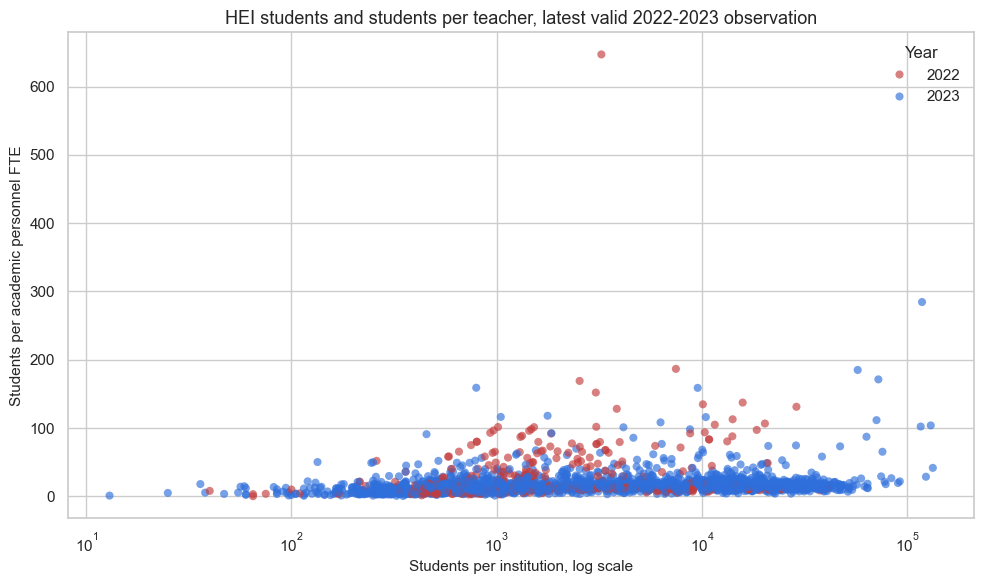

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=analysis_df,
    x="students_total_calc",
    y="students_per_teacher",
    hue="year",
    palette={2022: "#C43B3B", 2023: "#2F6FDB"},
    alpha=0.65,
    linewidth=0,
    s=34,
    ax=ax,
)

ax.set_xscale("log")
ax.set_title("HEI students and students per teacher, latest valid 2022-2023 observation")
ax.set_xlabel("Students per institution, log scale")
ax.set_ylabel("Students per academic personnel FTE")
ax.legend(title="Year", frameon=False)

plt.tight_layout()
save_figure("04_students_students_per_teacher_scatter_2022_2023.png", fig=fig)
plt.show()

## 10. Короткий висновок

In [42]:
print("Analytical sample")
print(coverage_summary.to_string())
print("\nOverall correlations")
print(correlation_all.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nCorrelations by year")
print(correlation_by_year.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nCountries with n >= 10")
print(country_counts.loc[country_counts["n_institutions"] >= MIN_COUNTRY_N].to_string(index=False))

Analytical sample
institutions                     1915.000000
countries                          27.000000
observations_2023                1633.000000
observations_2022                 282.000000
median_students                  3025.000000
median_academic_personnel_fte     190.000000
median_students_per_teacher        14.657895

Overall correlations
   group   method  correlation  p_value  n_institutions
all_heis  pearson       0.1295   0.0000            1915
all_heis spearman       0.2592   0.0000            1915

Correlations by year
 year   method  correlation  p_value  n_institutions
 2022  pearson       0.1064   0.0000            1816
 2022 spearman       0.2565   0.0000            1816
 2023  pearson       0.2615   0.0000            1633
 2023 spearman       0.2971   0.0000            1633

Countries with n >= 10
country_code  n_institutions
          DE             396
          PL             263
          IT             210
          UK             200
          PT         

## 11. Додане дослідження: студенти та фінансування на студента

Цей блок додає окреме дослідження до ноутбука й не використовує попередній Markdown-план як джерело логіки. Завдання - порахувати кореляції між кількістю студентів у ЗВО та фінансуванням у розрахунку на одного студента, використовуючи тільки валідні дані за 2022-2023 роки.


### План доданого дослідження

1. Взяти очищені дані `data/processed/df_base_clean.csv`, уже завантажені в `df`.
2. Залишити тільки рядки за 2022 і 2023 роки.
3. Розрахувати кількість студентів у ЗВО `students_total_calc`: `students_isced5_7_total + students_isced8`; якщо `students_isced5_7_total` відсутній, використати суму доступних рівнів ISCED 5, 6, 7 і 7 long degree.
4. Розрахувати фінансування на студента: основний показник `funding_per_student_ppp = total_current_expenditure_ppp / students_total_calc`; додатковий показник `funding_per_student_eur` зберегти для перевірки.
5. Виключити рядки без валідних даних за 2022-2023 роки: немає студентів, немає фінансування, нульові/від'ємні значення або неможливо порахувати фінансування на студента.
6. Для кожного ЗВО вибрати одне спостереження: спочатку 2023 рік, якщо він валідний; інакше 2022 рік.
7. Порахувати Pearson і Spearman кореляції по всій вибірці.
8. Порахувати Pearson і Spearman кореляції за країнами, де є мінімум `10` валідних ЗВО.
9. Порахувати кореляції окремо за 2022 і 2023 роками як аналіз чутливості.
10. Зберегти аналітичну вибірку, кореляції й таблицю винятків у `data/processed/`.
11. Побудувати діаграму розсіювання і зберегти його в `figures/` з префіксом `04_`.


### 11.1 Підготовка даних для фінансування на студента

In [43]:
finance_required_cols = [
    "country_code",
    "year",
    "institution_id",
    "institution_name_en",
    "students_isced5_7_total",
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
    "students_isced8",
    "total_current_expenditure_ppp",
    "total_current_expenditure_eur",
]

missing_finance_cols = [col for col in finance_required_cols if col not in df.columns]
if missing_finance_cols:
    raise KeyError(f"В df_base_clean.csv отсутствуют нужные колонки: {missing_finance_cols}")

finance_source_rows = len(df)
finance_rows_outside_2022_2023 = (~df["year"].isin([2022, 2023])).sum()
finance_work = df.loc[df["year"].isin([2022, 2023]), finance_required_cols].copy()

finance_numeric_cols = [
    "students_isced5_7_total",
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
    "students_isced8",
    "total_current_expenditure_ppp",
    "total_current_expenditure_eur",
]

for col in finance_numeric_cols:
    finance_work[col] = pd.to_numeric(finance_work[col], errors="coerce")

finance_isced_5_7_fallback = finance_work[[
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
]].sum(axis=1, min_count=1)

finance_students_5_7 = finance_work["students_isced5_7_total"].combine_first(finance_isced_5_7_fallback)
finance_work["students_total_calc"] = finance_students_5_7.add(
    finance_work["students_isced8"].fillna(0),
    fill_value=np.nan,
)

finance_work["funding_per_student_ppp"] = (
    finance_work["total_current_expenditure_ppp"] / finance_work["students_total_calc"]
)
finance_work["funding_per_student_eur"] = (
    finance_work["total_current_expenditure_eur"] / finance_work["students_total_calc"]
)

finance_work[
    [
        "students_total_calc",
        "total_current_expenditure_ppp",
        "funding_per_student_ppp",
        "total_current_expenditure_eur",
        "funding_per_student_eur",
    ]
].describe()

/Users/ssyvon41kkk/PycharmProjects/ETER.EDBO/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/ssyvon41kkk/PycharmProjects/ETER.EDBO/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,students_total_calc,total_current_expenditure_ppp,funding_per_student_ppp,total_current_expenditure_eur,funding_per_student_eur
count,6.336000e+03,2.536000e+03,2.535000e+03,2.536000e+03,2.535000e+03
mean,8.562446e+03,1.167138e+08,inf,1.348320e+08,inf
std,3.782760e+04,1.916360e+08,NaN,2.340155e+08,NaN
min,0.000000e+00,2.301836e+05,5.362788e+02,1.267200e+05,5.980474e+02
25%,4.880000e+02,1.187466e+07,7.144005e+03,1.280448e+07,7.473154e+03
50%,1.779000e+03,4.325589e+07,9.948082e+03,4.690989e+07,1.097215e+04
75%,9.430750e+03,1.370361e+08,1.629737e+04,1.514894e+08,1.826075e+04
max,1.891766e+06,2.387137e+09,inf,2.871222e+09,inf


### 11.2 Фільтрація валідних спостережень 2022-2023

In [44]:
finance_has_valid_students = (
    finance_work["students_total_calc"].notna() & (finance_work["students_total_calc"] > 0)
)
finance_has_valid_funding_ppp = (
    finance_work["total_current_expenditure_ppp"].notna()
    & (finance_work["total_current_expenditure_ppp"] > 0)
)
finance_has_valid_funding_per_student_ppp = (
    finance_work["funding_per_student_ppp"].replace([np.inf, -np.inf], np.nan).notna()
    & (finance_work["funding_per_student_ppp"] > 0)
)

finance_exclusions = pd.DataFrame(
    {
        "rule": [
            "source_rows",
            "excluded_rows_outside_2022_2023",
            "rows_in_2022_2023",
            "missing_students_total_calc",
            "zero_or_negative_students_total_calc",
            "missing_total_current_expenditure_ppp",
            "zero_or_negative_total_current_expenditure_ppp",
            "invalid_funding_per_student_ppp",
        ],
        "rows": [
            finance_source_rows,
            finance_rows_outside_2022_2023,
            len(finance_work),
            finance_work["students_total_calc"].isna().sum(),
            (finance_work["students_total_calc"].notna() & (finance_work["students_total_calc"] <= 0)).sum(),
            finance_work["total_current_expenditure_ppp"].isna().sum(),
            (
                finance_work["total_current_expenditure_ppp"].notna()
                & (finance_work["total_current_expenditure_ppp"] <= 0)
            ).sum(),
            (~finance_has_valid_funding_per_student_ppp).sum(),
        ],
    }
)

finance_valid = finance_work.loc[
    finance_has_valid_students
    & finance_has_valid_funding_ppp
    & finance_has_valid_funding_per_student_ppp
].copy()

finance_exclusions = pd.concat(
    [
        finance_exclusions,
        pd.DataFrame(
            {"rule": ["valid_rows_before_latest_year_selection"], "rows": [len(finance_valid)]}
        ),
    ],
    ignore_index=True,
)

finance_exclusions

,rule,rows
0,source_rows,29591
1,excluded_rows_outside_2022_2023,22989
2,rows_in_2022_2023,6602
3,missing_students_total_calc,266
4,zero_or_negative_students_total_calc,196
5,missing_total_current_expenditure_ppp,4066
6,zero_or_negative_total_current_expenditure_ppp,0
7,invalid_funding_per_student_ppp,4072
8,valid_rows_before_latest_year_selection,2530


### 11.3 Вибір останнього валідного року для кожного ЗВО

In [45]:
finance_analysis_df = (
    finance_valid.sort_values(["institution_id", "year"])
    .groupby("institution_id", as_index=False)
    .tail(1)
    .sort_values(["country_code", "institution_id"])
    .reset_index(drop=True)
)

finance_analysis_df = finance_analysis_df[
    [
        "country_code",
        "institution_id",
        "institution_name_en",
        "year",
        "students_total_calc",
        "total_current_expenditure_ppp",
        "funding_per_student_ppp",
        "total_current_expenditure_eur",
        "funding_per_student_eur",
    ]
].copy()

finance_exclusions = pd.concat(
    [
        finance_exclusions,
        pd.DataFrame(
            {
                "rule": ["valid_institutions_after_latest_year_selection"],
                "rows": [finance_analysis_df["institution_id"].nunique()],
            }
        ),
    ],
    ignore_index=True,
)

finance_coverage_summary = pd.Series(
    {
        "institutions": finance_analysis_df["institution_id"].nunique(),
        "countries": finance_analysis_df["country_code"].nunique(),
        "observations_2023": (finance_analysis_df["year"] == 2023).sum(),
        "observations_2022": (finance_analysis_df["year"] == 2022).sum(),
        "median_students": finance_analysis_df["students_total_calc"].median(),
        "median_funding_per_student_ppp": finance_analysis_df["funding_per_student_ppp"].median(),
        "median_funding_per_student_eur": finance_analysis_df["funding_per_student_eur"].median(),
    }
)

finance_coverage_summary

institutions                       1366.000000
countries                            26.000000
observations_2023                  1210.000000
observations_2022                   156.000000
median_students                    4286.500000
median_funding_per_student_ppp    10184.731881
median_funding_per_student_eur    11068.013313
dtype: float64

### 11.4 Кореляції

In [46]:
def finance_correlation_rows(
    data,
    group_label="all_heis",
    x_col="students_total_calc",
    y_col="funding_per_student_ppp",
):
    clean = data[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    n = len(clean)

    rows = []
    for method in ["pearson", "spearman"]:
        if n < 3 or clean[x_col].nunique() < 2 or clean[y_col].nunique() < 2:
            corr = np.nan
            p_value = np.nan
        elif stats is not None and method == "pearson":
            corr, p_value = stats.pearsonr(clean[x_col], clean[y_col])
        elif stats is not None and method == "spearman":
            corr, p_value = stats.spearmanr(clean[x_col], clean[y_col])
        else:
            corr = clean[x_col].corr(clean[y_col], method=method)
            p_value = np.nan

        rows.append(
            {
                "group": group_label,
                "method": method,
                "correlation": corr,
                "p_value": p_value,
                "n_institutions": n,
            }
        )

    return rows


def correlation_wide(correlation_df, group_col):
    wide = correlation_df.pivot(index=group_col, columns="method", values=["correlation", "p_value"])
    wide.columns = [f"{method}_{metric}" for metric, method in wide.columns]
    wide = wide.reset_index()

    n_by_group = correlation_df.groupby(group_col, as_index=False)["n_institutions"].max()
    return wide.merge(n_by_group, on=group_col, how="left")


FINANCE_MIN_COUNTRY_N = 10
FINANCE_MIN_YEAR_N = 3

finance_correlation_all = pd.DataFrame(finance_correlation_rows(finance_analysis_df))
finance_correlation_all_wide = correlation_wide(finance_correlation_all, "group")

finance_country_counts = (
    finance_analysis_df.groupby("country_code", as_index=False)
    .agg(n_institutions=("institution_id", "nunique"))
    .sort_values("n_institutions", ascending=False)
)
finance_eligible_countries = finance_country_counts.loc[
    finance_country_counts["n_institutions"] >= FINANCE_MIN_COUNTRY_N,
    "country_code",
]

finance_country_rows = []
for country_code, country_df in finance_analysis_df.loc[
    finance_analysis_df["country_code"].isin(finance_eligible_countries)
].groupby("country_code"):
    finance_country_rows.extend(finance_correlation_rows(country_df, group_label=country_code))

finance_correlation_by_country = pd.DataFrame(finance_country_rows).rename(columns={"group": "country_code"})
finance_correlation_by_country = finance_correlation_by_country.sort_values(
    ["method", "country_code"]
).reset_index(drop=True)
finance_correlation_by_country_wide = correlation_wide(
    finance_correlation_by_country,
    "country_code",
).sort_values("spearman_correlation", ascending=False)

finance_by_year_rows = []
for year, year_df in finance_valid.groupby("year"):
    if len(year_df) >= FINANCE_MIN_YEAR_N:
        finance_by_year_rows.extend(finance_correlation_rows(year_df, group_label=year))

finance_correlation_by_year = pd.DataFrame(finance_by_year_rows).rename(columns={"group": "year"})
finance_correlation_by_year = finance_correlation_by_year.sort_values(
    ["year", "method"]
).reset_index(drop=True)
finance_correlation_by_year_wide = correlation_wide(finance_correlation_by_year, "year")

print("Overall correlations")
display(finance_correlation_all_wide)

print("Country correlations, n >= 10, sorted by Spearman correlation")
display(finance_correlation_by_country_wide)

print("Correlations by year")
display(finance_correlation_by_year_wide)

Overall correlations


,group,pearson_correlation,spearman_correlation,pearson_p_value,spearman_p_value,n_institutions
0,all_heis,-0.037639,-0.093602,0.164422,0.000532,1366


Country correlations, n >= 10, sorted by Spearman correlation


,country_code,pearson_correlation,spearman_correlation,pearson_p_value,spearman_p_value,n_institutions
10,IE,0.577898,0.502941,0.019047,0.047063,16
11,LT,0.450832,0.385385,0.023710,0.057105,25
12,LV,0.185540,0.282051,0.364164,0.162719,26
8,FI,0.306608,0.242857,0.073218,0.159804,35
2,CH,0.263488,0.093725,0.105075,0.570362,39
17,PT,0.253022,0.071658,0.148799,0.687152,34
7,EE,0.151247,-0.077058,0.638912,0.811859,12
13,MT,-0.023593,-0.092857,0.933488,0.742045,15
1,BE,0.397870,-0.096104,0.074066,0.678583,21
20,UK,-0.071889,-0.133903,0.263301,0.036590,244


Correlations by year


,year,pearson_correlation,spearman_correlation,pearson_p_value,spearman_p_value,n_institutions
0,2022,-0.038177,-0.081922,0.165677,0.002896,1320
1,2023,-0.080173,-0.098338,0.005264,0.000614,1210


### 11.5 Збереження результатів

In [47]:
finance_analysis_path = OUTPUT_DIR / "students_funding_per_student_input_2022_2023.csv"
finance_correlation_all_path = OUTPUT_DIR / "students_funding_per_student_correlation_all_heis_2022_2023.csv"
finance_correlation_by_country_path = OUTPUT_DIR / "students_funding_per_student_correlation_by_country_2022_2023.csv"
finance_correlation_by_year_path = OUTPUT_DIR / "students_funding_per_student_correlation_by_year_2022_2023.csv"
finance_exclusions_path = OUTPUT_DIR / "students_funding_per_student_exclusions_2022_2023.csv"
finance_country_counts_path = OUTPUT_DIR / "students_funding_per_student_country_counts_2022_2023.csv"

finance_analysis_df.to_csv(finance_analysis_path, index=False)
finance_correlation_all.to_csv(finance_correlation_all_path, index=False)
finance_correlation_by_country.to_csv(finance_correlation_by_country_path, index=False)
finance_correlation_by_year.to_csv(finance_correlation_by_year_path, index=False)
finance_exclusions.to_csv(finance_exclusions_path, index=False)
finance_country_counts.to_csv(finance_country_counts_path, index=False)

for path in [
    finance_analysis_path,
    finance_correlation_all_path,
    finance_correlation_by_country_path,
    finance_correlation_by_year_path,
    finance_exclusions_path,
    finance_country_counts_path,
]:
    print(path.relative_to(PROJECT_ROOT))

data/processed/students_funding_per_student_input_2022_2023.csv
data/processed/students_funding_per_student_correlation_all_heis_2022_2023.csv
data/processed/students_funding_per_student_correlation_by_country_2022_2023.csv
data/processed/students_funding_per_student_correlation_by_year_2022_2023.csv
data/processed/students_funding_per_student_exclusions_2022_2023.csv
data/processed/students_funding_per_student_country_counts_2022_2023.csv


### 11.6 Візуалізація

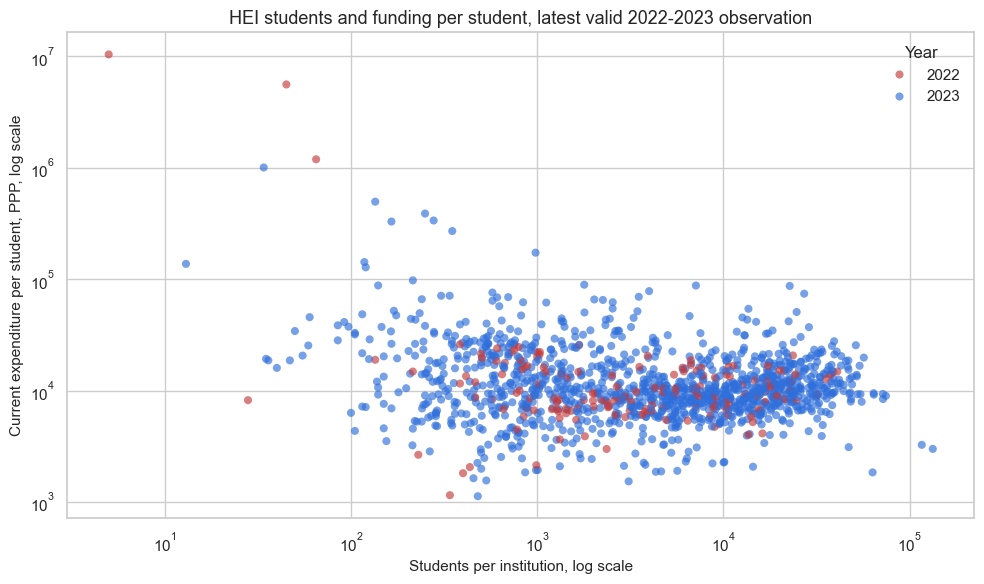

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=finance_analysis_df,
    x="students_total_calc",
    y="funding_per_student_ppp",
    hue="year",
    palette={2022: "#C43B3B", 2023: "#2F6FDB"},
    alpha=0.65,
    linewidth=0,
    s=34,
    ax=ax,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("HEI students and funding per student, latest valid 2022-2023 observation")
ax.set_xlabel("Students per institution, log scale")
ax.set_ylabel("Current expenditure per student, PPP, log scale")
ax.legend(title="Year", frameon=False)

plt.tight_layout()
save_figure("04_students_funding_per_student_scatter_2022_2023.png", fig=fig)
plt.show()

### 11.7 Короткий висновок щодо фінансування

In [49]:
print("Funding analytical sample")
print(finance_coverage_summary.to_string())
print("\nOverall funding correlations")
print(finance_correlation_all.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nFunding correlations by year")
print(finance_correlation_by_year.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nCountries with n >= 10")
print(
    finance_country_counts.loc[
        finance_country_counts["n_institutions"] >= FINANCE_MIN_COUNTRY_N
    ].to_string(index=False)
)

Funding analytical sample
institutions                       1366.000000
countries                            26.000000
observations_2023                  1210.000000
observations_2022                   156.000000
median_students                    4286.500000
median_funding_per_student_ppp    10184.731881
median_funding_per_student_eur    11068.013313

Overall funding correlations
   group   method  correlation  p_value  n_institutions
all_heis  pearson      -0.0376   0.1644            1366
all_heis spearman      -0.0936   0.0005            1366

Funding correlations by year
 year   method  correlation  p_value  n_institutions
 2022  pearson      -0.0382   0.1657            1320
 2022 spearman      -0.0819   0.0029            1320
 2023  pearson      -0.0802   0.0053            1210
 2023 spearman      -0.0983   0.0006            1210

Countries with n >= 10
country_code  n_institutions
          DE             398
          UK             244
          FR             121
          PL